"SpendLens"
 The Student Budget Intelligence Dashboard

**The Problem **

Students living in hostels, PGs, and shared apartments have no real visibility into where
their monthly budget actually goes. Canteen bills, food delivery, cab rides, and UPI
transfers pile up invisibly. By the end of the month, money is gone but no one knows
exactly why. The data exists; no one has made sense of it yet.

analyse the csv file.

check what categories or columns it has .


In [3]:
import pandas as pd
df = pd.read_csv("student_transactions.csv")
df.head()

,Date,Amount,Category,Merchant_Name,Payment_Mode
0,08-08-2024,6759.50,Utilities,PG_Rent,UPI
1,24-11-2024,141.71,Entertainment,Steam,Cash
2,08-09-2024,175.70,Food,Subway,UPI
3,28-09-2024,194.71,Transport,Uber,Cash
4,21-10-2024,542.00,Education,Coursera,Card


In [4]:
df.shape
df.columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1530 entries, 0 to 1529
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           1530 non-null   object 
 1   Amount         1530 non-null   float64
 2   Category       1469 non-null   object 
 3   Merchant_Name  1530 non-null   object 
 4   Payment_Mode   1530 non-null   object 
dtypes: float64(1), object(4)
memory usage: 59.9+ KB


In [5]:
df['Date'] = pd.to_datetime(df['Date'], format='mixed', dayfirst=True)

identifying null values

In [6]:
df['Category'] = df['Category'].fillna('Unknown')

In [7]:
df.isnull().sum()

,0
Date,0
Amount,0
Category,0
Merchant_Name,0
Payment_Mode,0


 Extract month and Extract day of week

In [8]:
df['Day'] = df['Date'].dt.day_name()
df['Month'] = df['Date'].dt.month_name()
df.head()

,Date,Amount,Category,Merchant_Name,Payment_Mode,Day,Month
0,2024-08-08,6759.50,Utilities,PG_Rent,UPI,Thursday,August
1,2024-11-24,141.71,Entertainment,Steam,Cash,Sunday,November
2,2024-09-08,175.70,Food,Subway,UPI,Sunday,September
3,2024-09-28,194.71,Transport,Uber,Cash,Saturday,September
4,2024-10-21,542.00,Education,Coursera,Card,Monday,October


Standardize category names

In [9]:
df['Category'] = df['Category'].str.strip().str.title()

In [10]:
category_spending = df.groupby('Category')['Amount'].sum().sort_values(ascending=False)
category_spending

,Amount
Category,
Utilities,154121.43
Education,119943.72
Food,95975.64
Entertainment,83929.23
Transport,40677.41
Unknown,21413.10


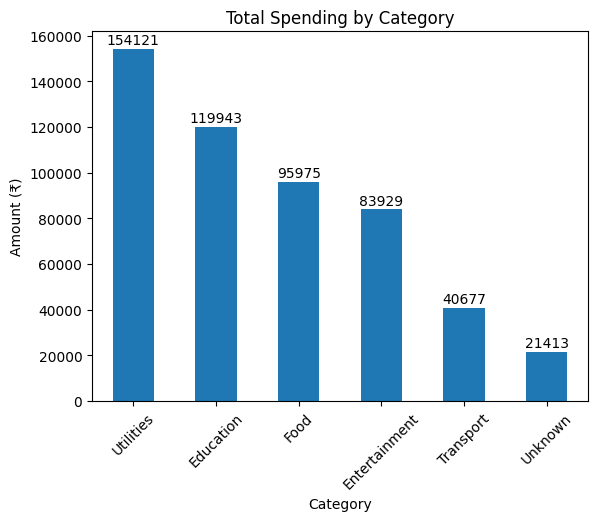

In [11]:
import matplotlib.pyplot as plt
for i, v in enumerate(category_spending):
    plt.text(i, v + 2000, f"{int(v)}", ha='center')
category_spending.plot(kind='bar')

plt.title("Total Spending by Category")
plt.xlabel("Category")
plt.ylabel("Amount (₹)")
plt.xticks(rotation=45)
plt.show()

In [12]:
day_spending = df.groupby('Day')['Amount'].sum()
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_spending = day_spending.reindex(days_order)

day_spending

,Amount
Day,
Monday,67023.58
Tuesday,68989.69
Wednesday,67805.93
Thursday,80059.78
Friday,67357.67
Saturday,79563.86
Sunday,85260.02


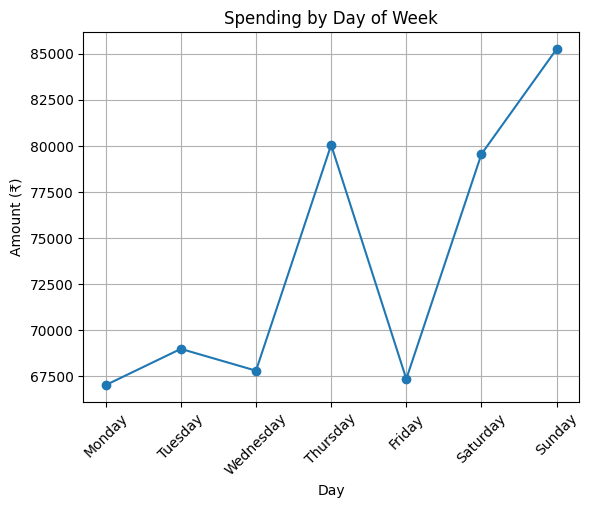

In [13]:
day_spending.plot(kind='line', marker='o')
plt.title("Spending by Day of Week")
plt.xlabel("Day")
plt.ylabel("Amount (₹)")
plt.xticks(rotation=45)
plt.grid()
plt.show()

In [16]:
monthly_spending = monthly_spending.dropna()
monthly_spending

,Amount
Month,
June,100203.14
July,81981.80
August,97020.51
September,77261.58
October,81900.30
November,77693.20


In [15]:
monthly_spending = df.groupby('Month')['Amount'].sum()
months_order = ['January', 'February', 'March', 'April', 'May', 'June',
                'July', 'August', 'September', 'October', 'November', 'December']

monthly_spending = monthly_spending.reindex(months_order)

monthly_spending

,Amount
Month,
January,NaN
February,NaN
March,NaN
April,NaN
May,NaN
June,100203.14
July,81981.80
August,97020.51
September,77261.58


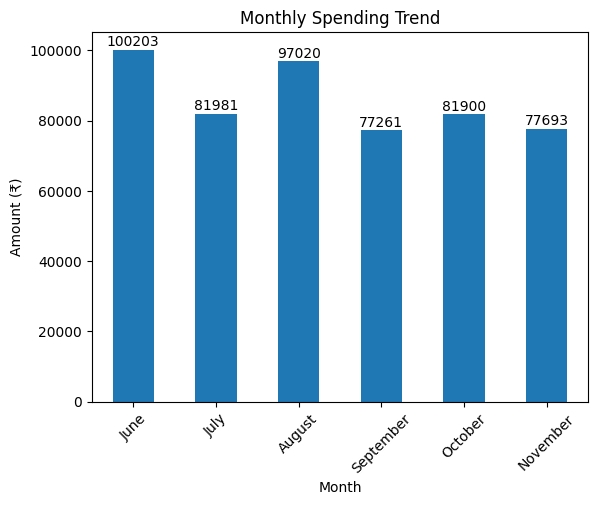

In [17]:
monthly_spending = monthly_spending.dropna()
monthly_spending.plot(kind='bar')
plt.title("Monthly Spending Trend")
plt.xlabel("Month")
plt.ylabel("Amount (₹)")
plt.xticks(rotation=45)

# add labels safely
for i, v in enumerate(monthly_spending):
    if pd.notnull(v):
        plt.text(i, v + 1000, f"{int(v)}", ha='center')

plt.show()

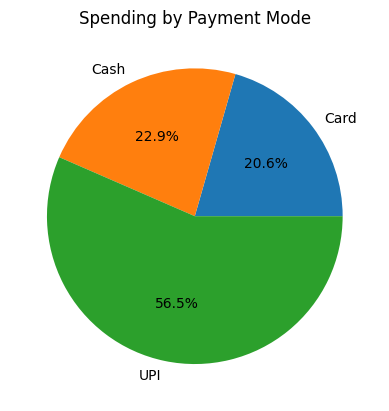

In [18]:
df.groupby('Payment_Mode')['Amount'].sum().plot(kind='pie', autopct='%1.1f%%')
plt.title("Spending by Payment Mode")
plt.ylabel('')
plt.show()

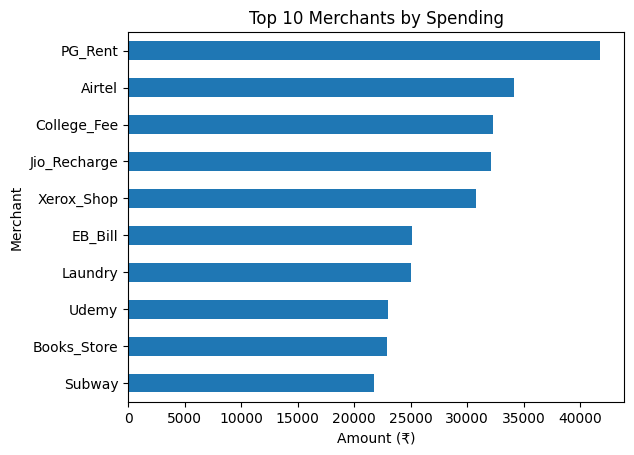

In [19]:
top_merchants = df.groupby('Merchant_Name')['Amount'].sum().sort_values(ascending=False).head(10)

top_merchants.plot(kind='barh')

plt.title("Top 10 Merchants by Spending")
plt.xlabel("Amount (₹)")
plt.ylabel("Merchant")
plt.gca().invert_yaxis()
plt.show()

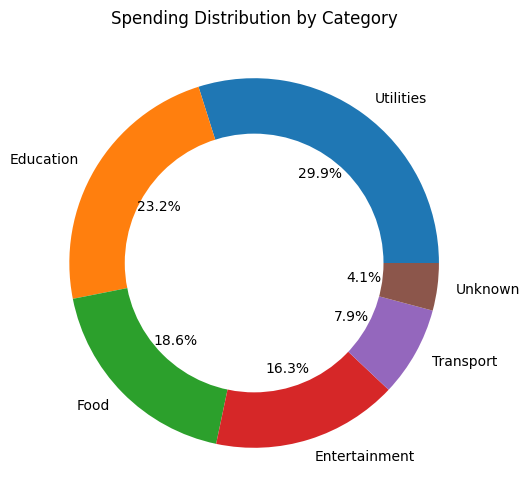

In [20]:
plt.figure(figsize=(6,6))

plt.pie(category_spending, labels=category_spending.index, autopct='%1.1f%%')

# make it donut
centre_circle = plt.Circle((0,0),0.70,fc='white')
plt.gca().add_artist(centre_circle)

plt.title("Spending Distribution by Category")
plt.show()

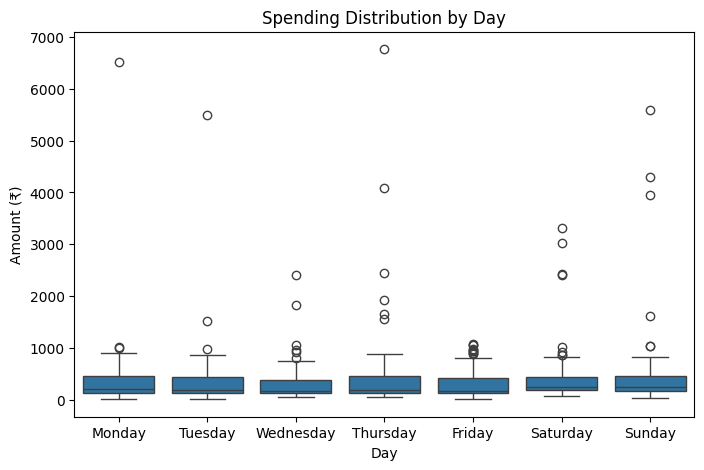

In [21]:
import seaborn as sns

plt.figure(figsize=(8,5))
sns.boxplot(x='Day', y='Amount', data=df,
            order=['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'])

plt.title("Spending Distribution by Day")
plt.xlabel("Day")
plt.ylabel("Amount (₹)")
plt.show()

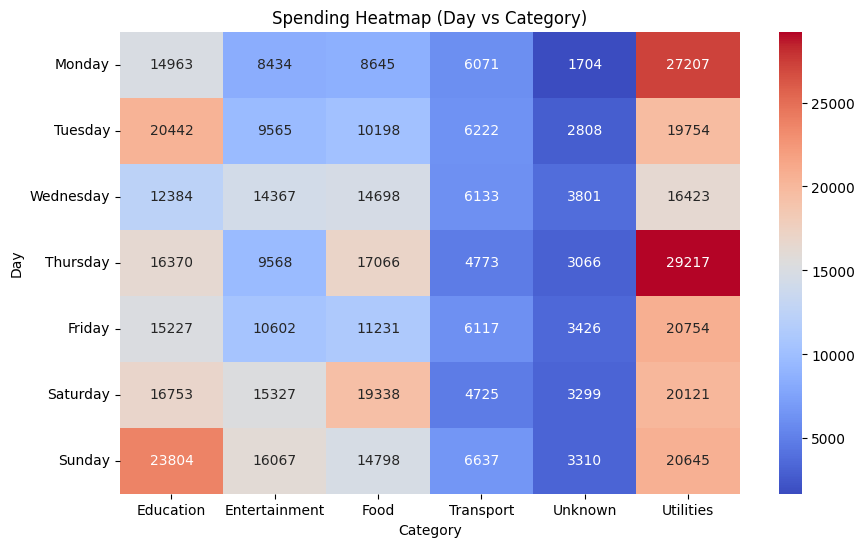

In [22]:
pivot = df.pivot_table(values='Amount', index='Day', columns='Category', aggfunc='sum')

pivot = pivot.reindex(['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'])

plt.figure(figsize=(10,6))
sns.heatmap(pivot, annot=True, fmt=".0f", cmap='coolwarm')

plt.title("Spending Heatmap (Day vs Category)")
plt.show()

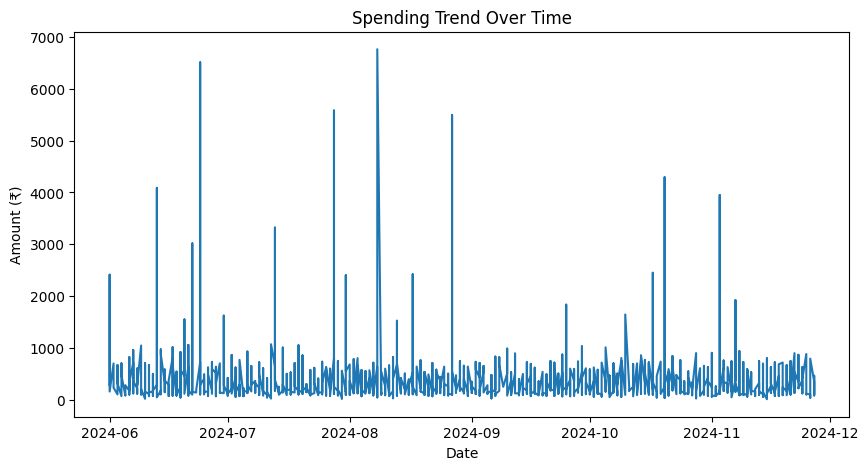

In [23]:
df_sorted = df.sort_values('Date')

plt.figure(figsize=(10,5))
plt.plot(df_sorted['Date'], df_sorted['Amount'])

plt.title("Spending Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Amount (₹)")
plt.show()

In [25]:
df.to_csv("cleaned_student_spending.csv", index=False)